In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
import joblib
from scipy.ndimage import uniform_filter1d

In [81]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib

def preprocess_character_image(image, size=(128, 128)):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    return resized

def detect_text_boxes(image, min_area=100):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mser = cv2.MSER_create()

    regions, _ = mser.detectRegions(gray)

    boxes = []
    for region in regions:
        x, y, w, h = cv2.boundingRect(region.reshape(-1, 1, 2))
        if w * h > min_area:
            boxes.append((x, y, w, h))

    return boxes

def merge_boxes(boxes, image_shape):
    mask = np.zeros(image_shape[:2], dtype=np.uint8)

    for (x, y, w, h) in boxes:
        mask[y:y+h, x:x+w] = 255

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    dilated = cv2.dilate(mask, kernel)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    merged = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        merged.append((x, y, w, h))

    return merged

def extract_regions(image, boxes):
    crops = []

    for (x, y, w, h) in boxes:
        crop = image[y:y+h, x:x+w]

        if crop.size > 0:
            crops.append(crop)

    return crops

def calc_gradients(image):
    Gx = np.array([[-1, 0, 1]], dtype=np.float32)
    Gy = np.array([[-1], [0], [1]], dtype=np.float32)

    image = image.astype(np.float32)

    gx = cv2.filter2D(image, -1, Gx)
    gy = cv2.filter2D(image, -1, Gy)
    
    gradients_magnitude = np.sqrt(gx**2 + gy**2)
    gradients_orientation = (np.arctan2(gy, gx) * 180 / np.pi) % 180

    return gradients_magnitude, gradients_orientation

def HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2):
    bin_size = 180 / num_bins

    # Defensive handling in case a color image slips through
    if orientations.ndim == 3:
        orientations = orientations.mean(axis=2)
    if magnitudes.ndim == 3:
        magnitudes = magnitudes.mean(axis=2)

    h, w = orientations.shape
    cells_y = h // cell_size
    cells_x = w // cell_size

    histograms = np.zeros((cells_y, cells_x, num_bins), dtype=np.float32)
    
    for cy in range(cells_y):
        for cx in range(cells_x):
            y0 = cy * cell_size
            x0 = cx * cell_size

            for y in range(cell_size):
                for x in range(cell_size):
                    angle = orientations[y0 + y, x0 + x]
                    mag = magnitudes[y0 + y, x0 + x]

                    bin_idx = int(angle / bin_size) % num_bins
                    histograms[cy, cx, bin_idx] += mag
                    
    features = []

    for y in range(cells_y - 1):
        for x in range(cells_x - 1):
            block = histograms[y:y+block_size, x:x+block_size].flatten()

            norm = np.linalg.norm(block)
            block = block / (norm + 1e-6)

            features.extend(block)

    return np.array(features, dtype=np.float32)

def get_text_parts(image_path):
    image = cv2.imread(image_path)

    boxes = detect_text_boxes(image)
    word_boxes = merge_boxes(boxes, image.shape)

    parts = extract_regions(image, word_boxes)

    return parts, image

def word_to_characters(word_image):
    gray = cv2.cvtColor(word_image, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # 🔥 use CLOSE not OPEN
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(clean, 8)

    char_images = []
    H, W = clean.shape

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]

        if 0.001 * H * W < area < 0.2 * H * W:
            char = clean[y:y+h, x:x+w]
            char_images.append((x, char))

    char_images = sorted(char_images, key=lambda c: c[0])

    return [c[1] for c in char_images]

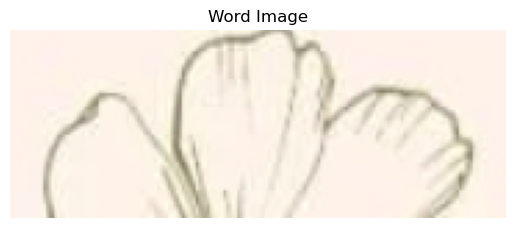

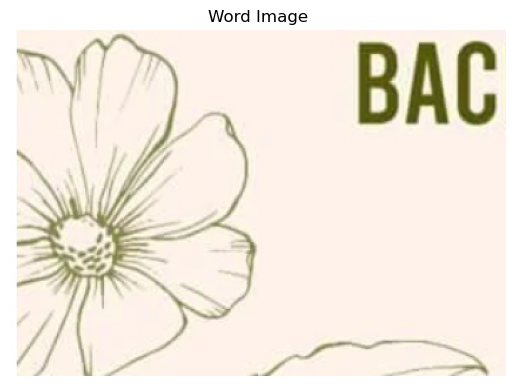

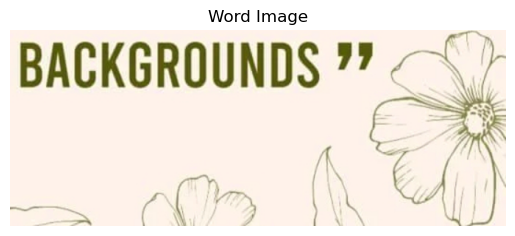

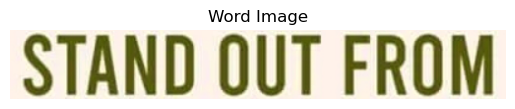

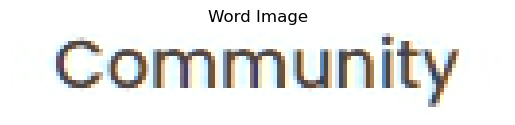

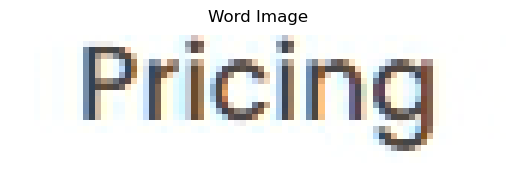

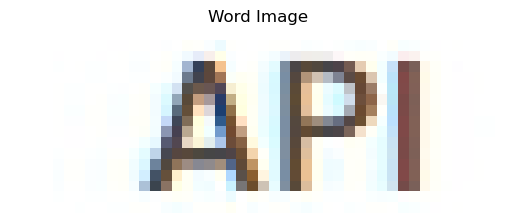

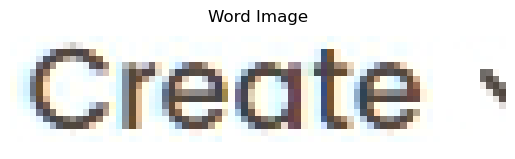

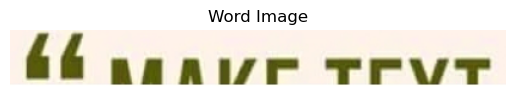

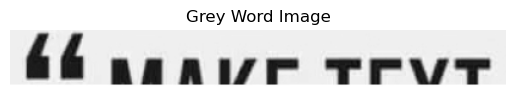

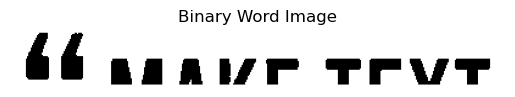

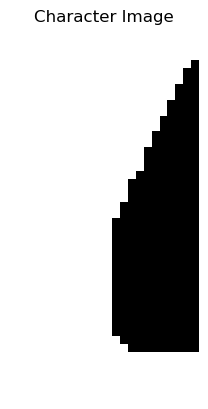

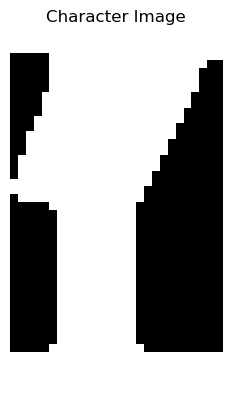

In [ ]:
# ===== MAIN USAGE =====

# Load your model
model = joblib.load("hog_manual_svm_model.joblib")
le = joblib.load("label_encoder.joblib")

# Get word parts



parts, original_image = get_text_parts("1.jpeg")
word = parts[4]
grey = cv2.cvtColor(word, cv2.COLOR_BGR2GRAY)
plt.imshow(grey, cmap='gray')
plt.title("Grey Word Image")
plt.axis('off')
plt.show()
## guassian blur to reduce noise
_, binary = cv2.threshold(grey, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(binary, cmap='gray')
plt.title("Binary Word Image")
plt.axis('off')
plt.show()

col_sum = np.sum(binary, axis=0)
threshold = 9  # columns with no ink
in_char = False
chars = []
i = 0
while i < len(col_sum):
    if col_sum[i] > threshold and not in_char:
        start = i
        in_char = True
    elif col_sum[i] <= threshold and in_char:
        end = i
        chars.append(binary[:, start:end])
        in_char = False
    i += 1

for char in chars:
    plt.imshow(char, cmap='gray')
    plt.title("Character Image")
    plt.axis('off')
    plt.show()  

    